# Gaussian Closure of Transport Dynamics

This notebook generates `fig:gradflow-gaussian-closure`.  Gaussian closure replaces a measure evolution by the evolution of its mean and covariance.  We compare three moment-level pictures between overlapping anisotropic Gaussians: the exact $W_2$ geodesic, a regularized Sinkhorn-like closure with inflated intermediate covariances, and a drifting closure with a curved mean path.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd()
if ROOT.name == "notebooks-figures":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "notebooks-figures"))

from figure_style import (
    BLUE,
    RED,
    VIOLET,
    ORANGE,
    GRAY,
    LIGHT_GRAY,
    DIRAC_MARKER_SIZE,
    box_axes,
    draw_point_clouds,
    draw_transport_segments,
    figure_dir,
    interp_color,
    padded_limits,
    remove_axes,
    save_pdf,
    setup_matplotlib,
)

setup_matplotlib()

from matplotlib.patches import Ellipse

NAME = "gradflow-gaussian-closure"
out = figure_dir(NAME)

Only ellipses are drawn.  This keeps the focus on the Gaussian manifold: affine tangent fields act on means and covariance matrices, while nonlinear dynamics must be projected back to these moments.

In [2]:
m0 = np.array([-0.58, -0.10])
m1 = np.array([0.62, 0.18])
C0 = np.array([[0.18, 0.065], [0.065, 0.075]])
C1 = np.array([[0.080, -0.045], [-0.045, 0.145]])
times = np.linspace(0, 1, 6)

def msqrt(A):
    vals, vecs = np.linalg.eigh(A)
    vals = np.maximum(vals, 1e-12)
    return (vecs * np.sqrt(vals)) @ vecs.T

def minvsqrt(A):
    vals, vecs = np.linalg.eigh(A)
    vals = np.maximum(vals, 1e-12)
    return (vecs * (1 / np.sqrt(vals))) @ vecs.T

def ellipse_params(C):
    vals, vecs = np.linalg.eigh(C)
    order = np.argsort(vals)[::-1]
    vals, vecs = vals[order], vecs[:, order]
    angle = np.degrees(np.arctan2(vecs[1,0], vecs[0,0]))
    return vals, angle

S0 = msqrt(C0)
A = minvsqrt(C0) @ msqrt(S0 @ C1 @ S0) @ minvsqrt(C0)

def w2_curve(t):
    B = (1-t) * np.eye(2) + t * A
    return (1-t)*m0 + t*m1, B @ C0 @ B.T

def sinkhorn_like_curve(t):
    m, C = w2_curve(t)
    return m, C + 0.080 * t * (1-t) * np.eye(2)

def drifting_curve(t):
    bend = np.array([0.00, 0.30]) * np.sin(np.pi*t)
    m = (1-t)*m0 + t*m1 + bend
    C = (1-t)*C0 + t*C1 + 0.030*np.sin(np.pi*t)*np.array([[0.7, 0.15], [0.15, 1.0]])
    return m, C

curves = {
    "ot-ellipses.pdf": [w2_curve(t) for t in times],
    "sinkhorn-ellipses.pdf": [sinkhorn_like_curve(t) for t in times],
    "drifting-ellipses.pdf": [drifting_curve(t) for t in times],
}
# Build limits from conservative ellipse extents to avoid cropped covariance displays.
ellipse_extent_points = []
for vals in curves.values():
    for m, C in vals:
        eigvals, _ = ellipse_params(C)
        radius = 1.45 * np.sqrt(eigvals.max())
        ellipse_extent_points.extend([m + [-radius, -radius], m + [radius, radius]])
ellipse_extent_points = np.asarray(ellipse_extent_points)
xlim, ylim = padded_limits(ellipse_extent_points, pad=0.14)

In [3]:
def draw_curve(vals, filename):
    fig, ax = plt.subplots(figsize=(2.42, 2.08))
    centers = np.array([m for m, C in vals])
    ax.plot(centers[:,0], centers[:,1], color=LIGHT_GRAY, lw=0.85, alpha=0.95, zorder=1)
    for k, (m, C) in enumerate(vals):
        color = interp_color(k/(len(vals)-1))
        eigvals, angle = ellipse_params(C)
        ell = Ellipse(m, width=2.35*np.sqrt(eigvals[0]), height=2.35*np.sqrt(eigvals[1]), angle=angle, facecolor=color, edgecolor="none", lw=0, alpha=0.20, zorder=2+k)
        ax.add_patch(ell)
        ax.add_patch(Ellipse(m, width=2.35*np.sqrt(eigvals[0]), height=2.35*np.sqrt(eigvals[1]), angle=angle, facecolor="none", edgecolor=color, lw=0.9, alpha=0.92, zorder=3+k))
        ax.scatter([m[0]], [m[1]], s=DIRAC_MARKER_SIZE * 0.38, marker="o", color=color, edgecolor="none", linewidth=0, zorder=8)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect("equal")
    remove_axes(ax)
    save_pdf(fig, out / filename, pad_inches=0.055)
    plt.close(fig)

for filename, vals in curves.items():
    draw_curve(vals, filename)
# Backward-compatible aliases for older gallery cards.
draw_curve(curves["drifting-ellipses.pdf"], "full-density-flow.pdf")
draw_curve(curves["ot-ellipses.pdf"], "gaussian-ellipses.pdf")

## Figure preview

The output below embeds the current generated thumbnail so the figure renders directly on GitHub.


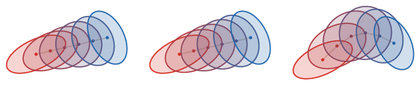

In [4]:
from pathlib import Path
from IPython.display import Image, display
_thumb = Path("thumbnails/gradflow-gaussian-closure.png")
if not _thumb.exists():
    _thumb = Path("notebooks-figures/thumbnails/gradflow-gaussian-closure.png")
display(Image(filename=str(_thumb)))
